In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
def read_data(data_path):
    """Read data from a directory of text files."""

    data = []
    file_names = os.listdir(data_path)
    file_names.sort(key=lambda x: int(x[:-4]))
    for file_name in file_names:
        file_path = os.path.join(data_path, file_name)
        signal_data = np.loadtxt(file_path)
        data.append(signal_data)
    data = np.array(data).transpose(0, 2, 1)
    d_shape = data.shape
    return data.reshape(d_shape[0], 1, d_shape[1], d_shape[2])


def read_label(data_path):
    """Read labels from a directory of text files."""

    data = []
    # 1.txt
    file_names = os.listdir(data_path)
    file_names.sort(key=lambda x: int(x[:-10]))
    for file_name in file_names:
        file_path = os.path.join(data_path, file_name)
        signal_data = np.loadtxt(file_path)
        data.append(signal_data)
    return np.array(data)


In [13]:

dataset_path = "../Gait-Datasets-TIFS20/Dataset #7"

train_data_path = os.path.join(dataset_path, "train", "train_data")
train_label_path = os.path.join(dataset_path, "train", "train_label")
test_data_path = os.path.join(dataset_path, "test", "test_data")
test_label_path = os.path.join(dataset_path, "test", "test_label")

train_data = read_data(train_data_path).transpose(0, 2, 3, 1)  # 519
train_label = read_label(train_label_path)
test_data = read_data(test_data_path).transpose(0, 2, 3, 1)  # 519
test_label = read_label(test_label_path)

print(train_data.shape)
print(train_label.shape)
print(test_data.shape)
print(test_label.shape)

# np.save("train_data.npy", train_data)
# np.save("train_label.npy", train_label)
# np.save("test_data.npy", test_data)
# np.save("test_label.npy", test_label)


(519, 6, 1024, 1)
(519, 1024)
(58, 6, 1024, 1)
(58, 1024)


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm


def cross_entropy(y_, output_map):
    """Same as nn.BCELoss but with added numerical stability."""
    output_map = torch.clamp(output_map, 1e-10, 1.0) # Clamp to avoid log(0)
    return -torch.mean(
        y_ * torch.log(output_map)
        + (1 - y_) * torch.log(torch.clamp(1 - output_map, 1e-10, 1.0))
    )


class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.conv1_1 = nn.Conv2d(1, 64, kernel_size=(1, 16), padding=0)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=(1, 16), padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=(1, 2), stride=(1, 2))

        self.conv2_2 = nn.Conv2d(64, 128, kernel_size=(1, 16), padding=0)
        self.conv2_3 = nn.Conv2d(128, 128, kernel_size=(1, 16), padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=(1, 2), stride=(1, 2))

        self.conv3_2 = nn.Conv2d(128, 256, kernel_size=(1, 16), padding=0)
        self.conv3_3 = nn.Conv2d(256, 256, kernel_size=(1, 16), padding=0)
        self.conv3_4 = nn.Conv2d(256, 256, kernel_size=(1, 16), padding=0)

        # Decoder
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=(1, 2), stride=(1, 2))
        self.conv2_5 = nn.Conv2d(256, 128, kernel_size=(1, 16), padding=0)
        self.conv2_6 = nn.Conv2d(128, 128, kernel_size=(1, 16), padding=0)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=(1, 2), stride=(1, 2))
        self.conv1_4a = nn.Conv2d(128, 64, kernel_size=(1, 16), padding=0)
        self.conv1_4b = nn.Conv2d(64, 64, kernel_size=(1, 16), padding=0)

        # Output head
        self.conv1_5 = nn.Conv2d(64, 256, kernel_size=(6, 1), padding=0)
        self.conv1_6 = nn.Conv2d(256, 1, kernel_size=(1, 1), padding=0)

    @staticmethod
    def reflect_pad(x, left, right):
        """
        Apply reflection padding to the width dimension of the input tensor.
        Args:
            x (torch.Tensor): Input tensor of shape (N, C, H, W).
            left (int): Amount of padding to add to the left side of the width dimension.
            right (int): Amount of padding to add to the right side of the width dimension.
        Returns:
            torch.Tensor: Padded tensor of shape (N, C, H, W + left + right).
        """

        return F.pad(x, (left, right, 0, 0), mode="reflect")

    def forward(self, x):
        # Encoder block 1
        x = self.reflect_pad(x, 7, 8)
        x = F.relu(self.conv1_1(x))
        x = self.reflect_pad(x, 7, 8)
        conv1_2 = F.relu(self.conv1_2(x))

        # Encoder block 2
        x = self.pool1(conv1_2)
        x = self.reflect_pad(x, 7, 8)
        x = F.relu(self.conv2_2(x))
        x = self.reflect_pad(x, 7, 8)
        conv2_3 = F.relu(self.conv2_3(x))

        # Encoder block 3
        x = self.pool2(conv2_3)
        x = self.reflect_pad(x, 7, 8)
        x = F.relu(self.conv3_2(x))
        x = self.reflect_pad(x, 7, 8)
        x = F.relu(self.conv3_3(x))
        x = self.reflect_pad(x, 7, 8)
        x = F.relu(self.conv3_4(x))

        # Decoder block 2
        x = self.up2(x)
        x = torch.cat([x, conv2_3], dim=1)
        x = self.reflect_pad(x, 7, 8)
        x = F.relu(self.conv2_5(x))
        x = self.reflect_pad(x, 7, 8)
        x = F.relu(self.conv2_6(x))

        # Decoder block 1
        x = self.up1(x)
        x = torch.cat([conv1_2, x], dim=1)
        x = self.reflect_pad(x, 7, 8)
        x = F.relu(self.conv1_4a(x))
        x = self.reflect_pad(x, 7, 8)
        x = F.relu(self.conv1_4b(x))

        # Output
        x = F.relu(self.conv1_5(x))
        x = torch.sigmoid(self.conv1_6(x))
        return x.view(-1, 1024)


In [ ]:
# Training Parameters
learning_rate = 0.00001
num_epochs = 1
batch_size = 5
display_step = 1
data_len = len(train_data)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.backends.mps.is_available() else device)
model = ConvNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

def batched_accuracy(data, labels):
    """
    Compute accuracy in batches to avoid memory issues.
    Args:
        data (np.ndarray): Input data of shape (N, 1, 6, 1024).
        labels (np.ndarray): Ground truth labels of shape (N, 1024).
    Returns:
        float: Average accuracy over the dataset.
    """
    accs = []
    for i in range(0, len(data), batch_size):
        # Reshape to (B, 1, 6, 1024) and move to device
        bx = torch.tensor(data[i:i+batch_size], dtype=torch.float32).permute(0, 3, 1, 2).to(device)
        by = torch.tensor(labels[i : i + batch_size], dtype=torch.float32).to(device)
        with torch.no_grad():
            pred = (model(bx) > 0.5).float()
        accs.append((pred == by).float().mean().item())
    return np.mean(accs)


num_batches = data_len // batch_size

for epoch in range(1, num_epochs + 1):
    model.train()

    # Shuffle the training data at the beginning of each epoch
    np.random.seed(epoch)
    indices = np.arange(train_data.shape[0])
    np.random.shuffle(indices)
    train_data_new  = train_data[indices]
    train_label_new = train_label[indices]

    start_point = 0
    end_point   = start_point + batch_size

    pbar = tqdm(total=num_batches, desc=f"Epoch {epoch}/{num_epochs}", leave=False)
    while end_point < data_len:
        batch_x = (
            torch.tensor(train_data_new[start_point:end_point], dtype=torch.float32)
            .permute(0, 3, 1, 2) # Reshape to (B, 1, 6, 1024)
            .to(device)
        )
        batch_y = torch.tensor(
            train_label_new[start_point:end_point], dtype=torch.float32
        ).to(device)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss   = cross_entropy(batch_y, logits)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            acc = (logits > 0.5).float().eq(batch_y).float().mean().item()

        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{acc:.3f}")
        pbar.update(1)

        start_point += batch_size
        end_point   += batch_size

    pbar.close()

    model.eval()
    test_acc = batched_accuracy(test_data, test_label)
    print(f"Epoch {epoch}/{num_epochs} — Test Accuracy: {test_acc:.3f}")

print("Optimization Finished!")

Epoch 1/1 — Test Accuracy: 0.619
Optimization Finished!


In [ ]:
# Save the model checkpoint
torch.save(model.state_dict(), "convnet_gait_detection.pth")

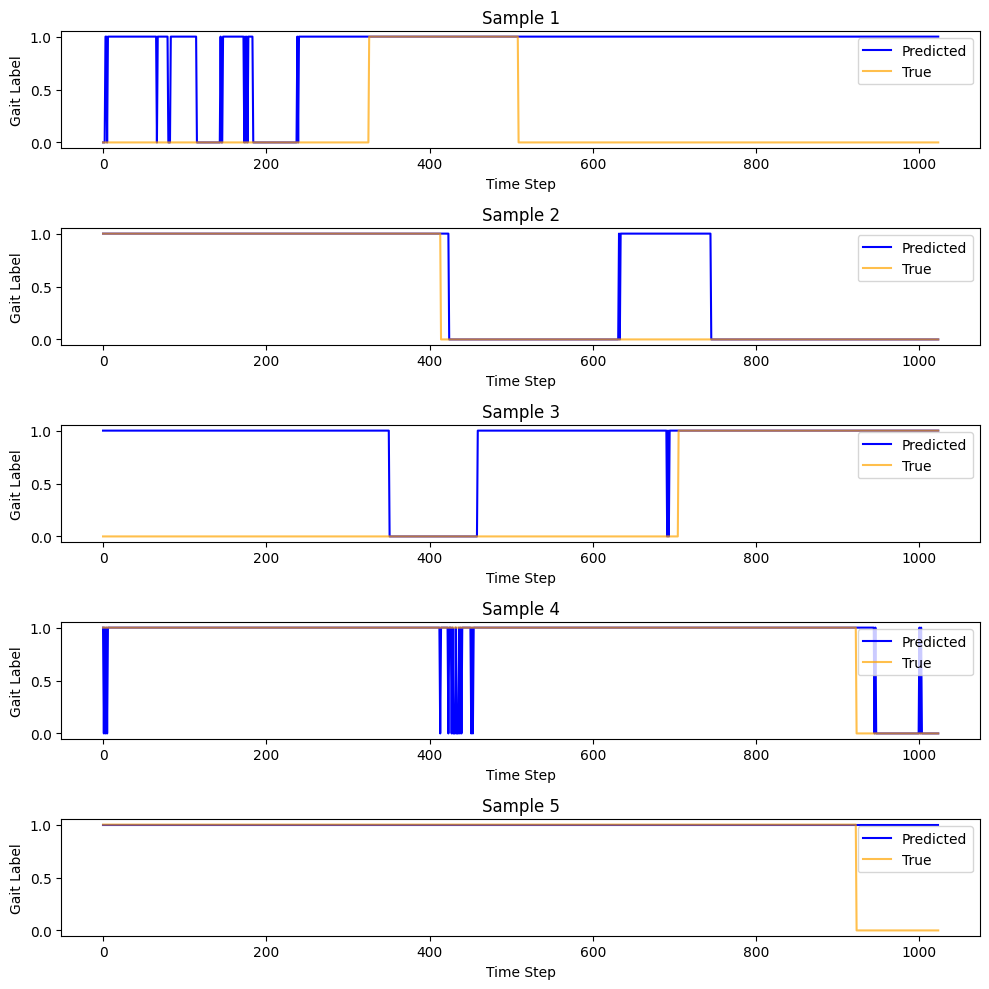

In [22]:
# Visualize some predictions using matplotlib
model.eval()
with torch.no_grad():
    sample_x = (
        torch.tensor(test_data[:5], dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    )
    sample_y = torch.tensor(test_label[:5], dtype=torch.float32).to(device)
    predictions = (model(sample_x) > 0.5).float().cpu().numpy()
    sample_y = sample_y.cpu().numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(predictions[i], label="Predicted", color="blue")
    plt.plot(sample_y[i], label="True", color="orange", alpha=0.7)
    plt.title(f"Sample {i + 1}")
    plt.xlabel("Time Step")
    plt.ylabel("Gait Label")
    plt.legend()
plt.tight_layout()
plt.show()
